In [1]:
!pip install transformers torch nltk rouge-score datasets

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=8fc390bffc7eefca9701b9632aeedda8f00466d771d3c874fccb473a3b9ae276
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [2]:
import torch
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from transformers import AutoModelForCausalLM, AutoTokenizer, BlenderbotTokenizer, BlenderbotForConditionalGeneration
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer

nltk.download('punkt')

print("All libraries imported successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported successfully!


In [3]:
test_inputs = [
    "Hello, how are you?",
    "What is artificial intelligence?",
    "Tell me something interesting.",
    "Can you help me with my problem?"
]

# Reff responses
reference_responses = [
    "I am doing well, thank you for asking!",
    "Artificial intelligence is the simulation of human intelligence by machines.",
    "Did you know honey never spoils? Archaeologists found 3000 year old honey in Egypt!",
    "Of course! I would be happy to help you. What is your problem?"
]

print("Test inputs defined!")
print(f"Total test cases: {len(test_inputs)}")

Test inputs defined!
Total test cases: 4


In [4]:
# Function to calculate BLEU score
def calculate_bleu(reference, hypothesis):
    reference_tokens = [reference.lower().split()]
    hypothesis_tokens = hypothesis.lower().split()
    smoothie = SmoothingFunction().method1  # handles short sentences
    score = sentence_bleu(reference_tokens, hypothesis_tokens, smoothing_function=smoothie)
    return round(score, 4)

# Function to calculate ROUGE score
def calculate_rouge(reference, hypothesis):
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    scores = scorer.score(reference, hypothesis)
    return round(scores['rougeL'].fmeasure, 4)

# Function to calculate perplexity
def calculate_perplexity(model, tokenizer, text):
    inputs = tokenizer(text, return_tensors='pt')
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs['input_ids'])
    loss = outputs.loss
    perplexity = torch.exp(loss).item()
    return round(perplexity, 4)

print("Helper functions defined!")

Helper functions defined!


#  DialoGPT Small

In [5]:
print("Loading DialoGPT-small...")
model_name = "microsoft/DialoGPT-small"
tokenizer_dgpt_s = AutoTokenizer.from_pretrained(model_name)
model_dgpt_s = AutoModelForCausalLM.from_pretrained(model_name)
model_dgpt_s.eval()

bleu_scores, rouge_scores, response_times, perplexities = [], [], [], []

for i, inp in enumerate(test_inputs):
    # Tokenize input
    input_ids = tokenizer_dgpt_s.encode(inp + tokenizer_dgpt_s.eos_token, return_tensors='pt')

    # Measure response time
    start = time.time()
    with torch.no_grad():
        output = model_dgpt_s.generate(input_ids, max_length=100,
                                        pad_token_id=tokenizer_dgpt_s.eos_token_id,
                                        do_sample=True, temperature=0.7)
    end = time.time()

    # Decode response
    response = tokenizer_dgpt_s.decode(output[:, input_ids.shape[-1]:][0], skip_special_tokens=True)
    if response == "":
        response = "I am not sure about that."

    # Calculate metrics
    bleu = calculate_bleu(reference_responses[i], response)
    rouge = calculate_rouge(reference_responses[i], response)
    perp = calculate_perplexity(model_dgpt_s, tokenizer_dgpt_s, inp)
    resp_time = round((end - start) * 1000, 2)

    bleu_scores.append(bleu)
    rouge_scores.append(rouge)
    response_times.append(resp_time)
    perplexities.append(perp)

    print(f"Input: {inp}")
    print(f"Response: {response}")
    print(f"BLEU: {bleu} | ROUGE: {rouge} | Time: {resp_time}ms | Perplexity: {perp}")
    print("---")

# Average scores for this model
dgpt_small_scores = {
    'Model': 'DialoGPT-small',
    'BLEU': round(np.mean(bleu_scores), 4),
    'Perplexity': round(np.mean(perplexities), 4),
    'ResponseTime': round(np.mean(response_times), 2),
    'ModelSize': 117,  # MB
    'ROUGE': round(np.mean(rouge_scores), 4)
}
print("\nFinal Scores for DialoGPT-small:")
print(dgpt_small_scores)

Loading DialoGPT-small...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/641 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: microsoft/DialoGPT-small
Key                              | Status     |  | 
---------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Input: Hello, how are you?
Response: hi everyone
BLEU: 0 | ROUGE: 0.0 | Time: 4878.39ms | Perplexity: 1504.2427
---
Input: What is artificial intelligence?
Response: We are artificial intelligence.
BLEU: 0.0179 | ROUGE: 0.2857 | Time: 7819.97ms | Perplexity: 44092.4609
---
Input: Tell me something interesting.
Response: I'm having a hard time getting into this as well.
BLEU: 0 | ROUGE: 0.0 | Time: 9622.88ms | Perplexity: 1100.5898
---
Input: Can you help me with my problem?
Response: Hey man I'm not able to help myself right now, but I will in about 3 hours, I'll PM you when I get home
BLEU: 0.0185 | ROUGE: 0.2051 | Time: 19757.56ms | Perplexity: 983.1965
---

Final Scores for DialoGPT-small:
{'Model': 'DialoGPT-small', 'BLEU': np.float64(0.0091), 'Perplexity': np.float64(11920.1225), 'ResponseTime': np.float64(10519.7), 'ModelSize': 117, 'ROUGE': np.float64(0.1227)}


#  DialoGPT Medium

In [6]:
print("Loading DialoGPT-medium...")
model_name = "microsoft/DialoGPT-medium"
tokenizer_dgpt_m = AutoTokenizer.from_pretrained(model_name)
model_dgpt_m = AutoModelForCausalLM.from_pretrained(model_name)
model_dgpt_m.eval()

bleu_scores, rouge_scores, response_times, perplexities = [], [], [], []

for i, inp in enumerate(test_inputs):
    input_ids = tokenizer_dgpt_m.encode(inp + tokenizer_dgpt_m.eos_token, return_tensors='pt')

    start = time.time()
    with torch.no_grad():
        output = model_dgpt_m.generate(input_ids, max_length=100,
                                        pad_token_id=tokenizer_dgpt_m.eos_token_id,
                                        do_sample=True, temperature=0.7)
    end = time.time()

    response = tokenizer_dgpt_m.decode(output[:, input_ids.shape[-1]:][0], skip_special_tokens=True)
    if response == "":
        response = "I am not sure about that."

    bleu = calculate_bleu(reference_responses[i], response)
    rouge = calculate_rouge(reference_responses[i], response)
    perp = calculate_perplexity(model_dgpt_m, tokenizer_dgpt_m, inp)
    resp_time = round((end - start) * 1000, 2)

    bleu_scores.append(bleu)
    rouge_scores.append(rouge)
    response_times.append(resp_time)
    perplexities.append(perp)

    print(f"Input: {inp}")
    print(f"Response: {response}")
    print(f"BLEU: {bleu} | ROUGE: {rouge} | Time: {resp_time}ms | Perplexity: {perp}")
    print("---")

dgpt_medium_scores = {
    'Model': 'DialoGPT-medium',
    'BLEU': round(np.mean(bleu_scores), 4),
    'Perplexity': round(np.mean(perplexities), 4),
    'ResponseTime': round(np.mean(response_times), 2),
    'ModelSize': 345,
    'ROUGE': round(np.mean(rouge_scores), 4)
}
print("\nFinal Scores for DialoGPT-medium:")
print(dgpt_medium_scores)

Loading DialoGPT-medium...


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/863M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: microsoft/DialoGPT-medium
Key                              | Status     |  | 
---------------------------------+------------+--+-
transformer.h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Input: Hello, how are you?
Response: Fine, thanks. How are you?
BLEU: 0 | ROUGE: 0.3077 | Time: 29588.72ms | Perplexity: 180.1136
---
Input: What is artificial intelligence?
Response: Like a computer, except it can't detect sarcasm
BLEU: 0 | ROUGE: 0.0 | Time: 28495.16ms | Perplexity: 1653.6384
---
Input: Tell me something interesting.
Response: I think he's referring to the fact that the last time a person was arrested for something that was in the middle of a court case was in 2005.
BLEU: 0.0065 | ROUGE: 0.0455 | Time: 72084.75ms | Perplexity: 443.9188
---
Input: Can you help me with my problem?
Response: No. I'm not a legal guardian.
BLEU: 0 | ROUGE: 0.1 | Time: 28402.0ms | Perplexity: 105.7367
---

Final Scores for DialoGPT-medium:
{'Model': 'DialoGPT-medium', 'BLEU': np.float64(0.0016), 'Perplexity': np.float64(595.8519), 'ResponseTime': np.float64(39642.66), 'ModelSize': 345, 'ROUGE': np.float64(0.1133)}


# DialoGPT Large

In [7]:
print("Loading DialoGPT-large...")
model_name = "microsoft/DialoGPT-large"
tokenizer_dgpt_l = AutoTokenizer.from_pretrained(model_name)
model_dgpt_l = AutoModelForCausalLM.from_pretrained(model_name)
model_dgpt_l.eval()

bleu_scores, rouge_scores, response_times, perplexities = [], [], [], []

for i, inp in enumerate(test_inputs):
    input_ids = tokenizer_dgpt_l.encode(inp + tokenizer_dgpt_l.eos_token, return_tensors='pt')

    start = time.time()
    with torch.no_grad():
        output = model_dgpt_l.generate(input_ids, max_length=100,
                                        pad_token_id=tokenizer_dgpt_l.eos_token_id,
                                        do_sample=True, temperature=0.7)
    end = time.time()

    response = tokenizer_dgpt_l.decode(output[:, input_ids.shape[-1]:][0], skip_special_tokens=True)
    if response == "":
        response = "I am not sure about that."

    bleu = calculate_bleu(reference_responses[i], response)
    rouge = calculate_rouge(reference_responses[i], response)
    perp = calculate_perplexity(model_dgpt_l, tokenizer_dgpt_l, inp)
    resp_time = round((end - start) * 1000, 2)

    bleu_scores.append(bleu)
    rouge_scores.append(rouge)
    response_times.append(resp_time)
    perplexities.append(perp)

    print(f"Input: {inp}")
    print(f"Response: {response}")
    print(f"BLEU: {bleu} | ROUGE: {rouge} | Time: {resp_time}ms | Perplexity: {perp}")
    print("---")

dgpt_large_scores = {
    'Model': 'DialoGPT-large',
    'BLEU': round(np.mean(bleu_scores), 4),
    'Perplexity': round(np.mean(perplexities), 4),
    'ResponseTime': round(np.mean(response_times), 2),
    'ModelSize': 762,
    'ROUGE': round(np.mean(rouge_scores), 4)
}
print("\nFinal Scores for DialoGPT-large:")
print(dgpt_large_scores)

Loading DialoGPT-large...


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.75G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/437 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.wte.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
GPT2LMHeadModel LOAD REPORT from: microsoft/DialoGPT-large
Key                              | Status     |  | 
---------------------------------+------------+--+-
transformer.h.{0...35}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Input: Hello, how are you?
Response: I'm awesome.
BLEU: 0 | ROUGE: 0.1818 | Time: 43747.74ms | Perplexity: 3094.6313
---
Input: What is artificial intelligence?
Response: Computer AI
BLEU: 0 | ROUGE: 0.0 | Time: 24844.44ms | Perplexity: 39030.0938
---
Input: Tell me something interesting.
Response: You like girls
BLEU: 0.0029 | ROUGE: 0.1176 | Time: 27962.42ms | Perplexity: 583.9132
---
Input: Can you help me with my problem?
Response: I'll help you with that.
BLEU: 0.0108 | ROUGE: 0.3158 | Time: 50264.88ms | Perplexity: 356.7971
---

Final Scores for DialoGPT-large:
{'Model': 'DialoGPT-large', 'BLEU': np.float64(0.0034), 'Perplexity': np.float64(10766.3589), 'ResponseTime': np.float64(36704.87), 'ModelSize': 762, 'ROUGE': np.float64(0.1538)}


# BlenderBot-400M

In [8]:
from transformers import BlenderbotTokenizer, BlenderbotForConditionalGeneration

print("Loading BlenderBot-400M...")
model_name = "facebook/blenderbot-400M-distill"
tokenizer_bb = BlenderbotTokenizer.from_pretrained(model_name)
model_bb = BlenderbotForConditionalGeneration.from_pretrained(model_name)
model_bb.eval()

bleu_scores, rouge_scores, response_times = [], [], []

for i, inp in enumerate(test_inputs):
    inputs = tokenizer_bb(inp, return_tensors='pt')

    start = time.time()
    with torch.no_grad():
        output = model_bb.generate(**inputs, max_length=100)
    end = time.time()

    response = tokenizer_bb.decode(output[0], skip_special_tokens=True)
    if response == "":
        response = "I am not sure about that."

    bleu = calculate_bleu(reference_responses[i], response)
    rouge = calculate_rouge(reference_responses[i], response)
    resp_time = round((end - start) * 1000, 2)

    bleu_scores.append(bleu)
    rouge_scores.append(rouge)
    response_times.append(resp_time)

    print(f"Input: {inp}")
    print(f"Response: {response}")
    print(f"BLEU: {bleu} | ROUGE: {rouge} | Time: {resp_time}ms")
    print("---")

bb_400m_scores = {
    'Model': 'BlenderBot-400M',
    'BLEU': round(np.mean(bleu_scores), 4),
    'Perplexity': 30.0,  # approximate
    'ResponseTime': round(np.mean(response_times), 2),
    'ModelSize': 400,
    'ROUGE': round(np.mean(rouge_scores), 4)
}
print("\nFinal Scores for BlenderBot-400M:")
print(bb_400m_scores)

Loading BlenderBot-400M...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/16.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/730M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/355 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

Input: Hello, how are you?
Response:  I'm doing well, thank you. How are you this evening? Do you have any plans?
BLEU: 0.0703 | ROUGE: 0.4167 | Time: 24356.25ms
---
Input: What is artificial intelligence?
Response:  It is the study of human behavior and how it affects the physical, mental, social, and intellectual development of a person.
BLEU: 0.0273 | ROUGE: 0.2581 | Time: 24751.05ms
---
Input: Tell me something interesting.
Response:  Well, I'm going on a cruise to the Bahamas in a few weeks. I can't wait!
BLEU: 0.0123 | ROUGE: 0.0625 | Time: 24657.26ms
---
Input: Can you help me with my problem?
Response:  Sure, what kind of problem are you having? I can help you if you'd like.
BLEU: 0.0187 | ROUGE: 0.2759 | Time: 17545.21ms
---

Final Scores for BlenderBot-400M:
{'Model': 'BlenderBot-400M', 'BLEU': np.float64(0.0322), 'Perplexity': 30.0, 'ResponseTime': np.float64(22827.44), 'ModelSize': 400, 'ROUGE': np.float64(0.2533)}


#  GPT-2

In [9]:
print("Loading GPT-2...")
model_name = "gpt2"
tokenizer_gpt2 = AutoTokenizer.from_pretrained(model_name)
tokenizer_gpt2.pad_token = tokenizer_gpt2.eos_token  # gpt2 has no pad token by default
model_gpt2 = AutoModelForCausalLM.from_pretrained(model_name)
model_gpt2.eval()

bleu_scores, rouge_scores, response_times, perplexities = [], [], [], []

for i, inp in enumerate(test_inputs):
    input_ids = tokenizer_gpt2.encode(inp, return_tensors='pt')

    start = time.time()
    with torch.no_grad():
        output = model_gpt2.generate(input_ids, max_length=100,
                                      pad_token_id=tokenizer_gpt2.eos_token_id,
                                      do_sample=True, temperature=0.7)
    end = time.time()

    response = tokenizer_gpt2.decode(output[0][input_ids.shape[-1]:], skip_special_tokens=True)
    if response == "":
        response = "I am not sure about that."

    bleu = calculate_bleu(reference_responses[i], response)
    rouge = calculate_rouge(reference_responses[i], response)
    perp = calculate_perplexity(model_gpt2, tokenizer_gpt2, inp)
    resp_time = round((end - start) * 1000, 2)

    bleu_scores.append(bleu)
    rouge_scores.append(rouge)
    response_times.append(resp_time)
    perplexities.append(perp)

    print(f"Input: {inp}")
    print(f"Response: {response}")
    print(f"BLEU: {bleu} | ROUGE: {rouge} | Time: {resp_time}ms | Perplexity: {perp}")
    print("---")

gpt2_scores = {
    'Model': 'GPT-2',
    'BLEU': round(np.mean(bleu_scores), 4),
    'Perplexity': round(np.mean(perplexities), 4),
    'ResponseTime': round(np.mean(response_times), 2),
    'ModelSize': 117,
    'ROUGE': round(np.mean(rouge_scores), 4)
}
print("\nFinal Scores for GPT-2:")
print(gpt2_scores)

Loading GPT-2...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Input: Hello, how are you?
Response: 

You are good.

I love you. Thank you.

How are you?

I love you. Thank you.

Thank you.

How are you?

I love you. Thank you.

Thank you.

How are you?

I love you. Thank you.

Thank you.

How are you?

I love you. Thank you.

Thank you
BLEU: 0.009 | ROUGE: 0.1071 | Time: 6181.49ms | Perplexity: 10.3219
---
Input: What is artificial intelligence?
Response: 

A new kind of artificial intelligence is something that is going to change the way we think about intelligence. Every day, we will see new technologies that will make it possible to solve new problems without necessarily needing to use human hands. But what this new kind of AI doesn't do is solve a problem.

It does not solve a problem. It uses existing data and data from existing AI systems. It needs to be able to solve a problem, and it needs
BLEU: 0.0128 | ROUGE: 0.1064 | Time: 6518.82ms | Perplexity: 36.0772
---
Input: Tell me something interesting.
Response:  Do you have any idea what tha

# GPT-2 Medium

In [10]:
print("Loading GPT-2 Medium...")
model_name = "gpt2-medium"
tokenizer_gpt2m = AutoTokenizer.from_pretrained(model_name)
tokenizer_gpt2m.pad_token = tokenizer_gpt2m.eos_token
model_gpt2m = AutoModelForCausalLM.from_pretrained(model_name)
model_gpt2m.eval()

bleu_scores, rouge_scores, response_times, perplexities = [], [], [], []

for i, inp in enumerate(test_inputs):
    input_ids = tokenizer_gpt2m.encode(inp, return_tensors='pt')

    start = time.time()
    with torch.no_grad():
        output = model_gpt2m.generate(input_ids, max_length=100,
                                       pad_token_id=tokenizer_gpt2m.eos_token_id,
                                       do_sample=True, temperature=0.7)
    end = time.time()

    response = tokenizer_gpt2m.decode(output[0][input_ids.shape[-1]:], skip_special_tokens=True)
    if response == "":
        response = "I am not sure about that."

    bleu = calculate_bleu(reference_responses[i], response)
    rouge = calculate_rouge(reference_responses[i], response)
    perp = calculate_perplexity(model_gpt2m, tokenizer_gpt2m, inp)
    resp_time = round((end - start) * 1000, 2)

    bleu_scores.append(bleu)
    rouge_scores.append(rouge)
    response_times.append(resp_time)
    perplexities.append(perp)

    print(f"Input: {inp}")
    print(f"Response: {response}")
    print(f"BLEU: {bleu} | ROUGE: {rouge} | Time: {resp_time}ms | Perplexity: {perp}")
    print("---")

gpt2_medium_scores = {
    'Model': 'GPT-2-Medium',
    'BLEU': round(np.mean(bleu_scores), 4),
    'Perplexity': round(np.mean(perplexities), 4),
    'ResponseTime': round(np.mean(response_times), 2),
    'ModelSize': 345,
    'ROUGE': round(np.mean(rouge_scores), 4)
}
print("\nFinal Scores for GPT-2-Medium:")
print(gpt2_medium_scores)

Loading GPT-2 Medium...


config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Input: Hello, how are you?
Response:  I've got a pretty good idea of how you're feeling right now. You're a little more relaxed, but you're not quite at ease with your surroundings.

Well, it's all right. I've seen it all before…

You mean, you've seen it all?

Oh, yes. I've seen it, my friend! I've seen it all!

Well, that's why I'm telling you now. I
BLEU: 0.004 | ROUGE: 0.0759 | Time: 17832.14ms | Perplexity: 5.3718
---
Input: What is artificial intelligence?
Response:  AI is a concept that describes machines that have been trained to perform a specific task and are able to understand its instructions better than humans. At the present time, AI is mainly being used in self-driving cars, but it could also be used to help people with disabilities, as explained by a recent report from the National Academy of Sciences.

A new artificial intelligence technology has been developed that can identify specific faces using the human brain's ability to recognize faces. The AI
BLEU: 0.0062 | RO

In [11]:
all_results = [
    dgpt_small_scores,
    dgpt_medium_scores,
    dgpt_large_scores,
    bb_400m_scores,
    gpt2_scores,
    gpt2_medium_scores
]

df = pd.DataFrame(all_results)
print("="*60)
print("COMBINED RESULTS OF ALL MODELS")
print("="*60)
print(df.to_string(index=False))

df.to_csv('model_results.csv', index=False)
print("\nSaved to model_results.csv ")

COMBINED RESULTS OF ALL MODELS
          Model   BLEU  Perplexity  ResponseTime  ModelSize  ROUGE
 DialoGPT-small 0.0091  11920.1225      10519.70        117 0.1227
DialoGPT-medium 0.0016    595.8519      39642.66        345 0.1133
 DialoGPT-large 0.0034  10766.3589      36704.87        762 0.1538
BlenderBot-400M 0.0322     30.0000      22827.44        400 0.2533
          GPT-2 0.0070     31.0224       6258.08        117 0.0917
   GPT-2-Medium 0.0041     14.7620      16212.69        345 0.0683

Saved to model_results.csv 


In [12]:
print("="*60)
print("APPLYING TOPSIS METHOD")
print("="*60)

# Load the saved results
df = pd.read_csv('model_results.csv')
print("Loaded Data:")
print(df.to_string(index=False))

criteria = ['BLEU', 'Perplexity', 'ResponseTime', 'ModelSize', 'ROUGE']
matrix = df[criteria].values.astype(float)

# --- 7.1 Normalize ---
print("\n--- Step 7.1: Normalizing Matrix ---")
norm_matrix = matrix / np.sqrt((matrix**2).sum(axis=0))
norm_df = pd.DataFrame(norm_matrix, columns=criteria, index=df['Model'])
print(norm_df)

# --- 7.2 Apply Weights ---
print("\n--- Step 7.2: Applying Weights ---")
weights = np.array([0.25, 0.20, 0.20, 0.15, 0.20])
weighted_matrix = norm_matrix * weights
weighted_df = pd.DataFrame(weighted_matrix, columns=criteria, index=df['Model'])
print(weighted_df)

# --- 7.3 Ideal Best and Worst ---
print("\n--- Step 7.3: Ideal Best and Ideal Worst ---")
impacts = ['+', '-', '-', '-', '+']

ideal_best = []
ideal_worst = []

for j, impact in enumerate(impacts):
    if impact == '+':
        ideal_best.append(weighted_matrix[:, j].max())
        ideal_worst.append(weighted_matrix[:, j].min())
    else:
        ideal_best.append(weighted_matrix[:, j].min())
        ideal_worst.append(weighted_matrix[:, j].max())

print(f"Ideal Best:  {[round(x,4) for x in ideal_best]}")
print(f"Ideal Worst: {[round(x,4) for x in ideal_worst]}")

# --- 7.4 Euclidean Distances ---
print("\n--- Step 7.4: Euclidean Distances ---")
d_best = np.sqrt(((weighted_matrix - ideal_best)**2).sum(axis=1))
d_worst = np.sqrt(((weighted_matrix - ideal_worst)**2).sum(axis=1))

for i, model in enumerate(df['Model']):
    print(f"{model} → D_best: {round(d_best[i],4)} | D_worst: {round(d_worst[i],4)}")

# --- 7.5 TOPSIS Score and Ranking ---
print("\n--- Step 7.5: TOPSIS Scores and Ranking ---")
topsis_score = d_worst / (d_best + d_worst)

df['Distance_Best'] = d_best.round(4)
df['Distance_Worst'] = d_worst.round(4)
df['TOPSIS_Score'] = topsis_score.round(4)
df['Rank'] = df['TOPSIS_Score'].rank(ascending=False).astype(int)

final_df = df.sort_values('Rank')
print("\n FINAL TOPSIS RANKING:")
print(final_df[['Model','BLEU','Perplexity','ResponseTime',
                 'ModelSize','ROUGE','TOPSIS_Score','Rank']].to_string(index=False))

final_df.to_csv('topsis_results.csv', index=False)
print("\nSaved to topsis_results.csv ✅")

APPLYING TOPSIS METHOD
Loaded Data:
          Model   BLEU  Perplexity  ResponseTime  ModelSize  ROUGE
 DialoGPT-small 0.0091  11920.1225      10519.70        117 0.1227
DialoGPT-medium 0.0016    595.8519      39642.66        345 0.1133
 DialoGPT-large 0.0034  10766.3589      36704.87        762 0.1538
BlenderBot-400M 0.0322     30.0000      22827.44        400 0.2533
          GPT-2 0.0070     31.0224       6258.08        117 0.0917
   GPT-2-Medium 0.0041     14.7620      16212.69        345 0.0683

--- Step 7.1: Normalizing Matrix ---
                     BLEU  Perplexity  ResponseTime  ModelSize     ROUGE
Model                                                                   
DialoGPT-small   0.262740    0.741596      0.169484   0.116646  0.341915
DialoGPT-medium  0.046196    0.037070      0.638687   0.343957  0.315721
DialoGPT-large   0.098167    0.669816      0.591356   0.759697  0.428578
BlenderBot-400M  0.929697    0.001866      0.367775   0.398791  0.705844
GPT-2            0.

In [13]:
print("="*60)
print("APPLYING TOPSIS METHOD")
print("="*60)

# Load the saved results
df = pd.read_csv('model_results.csv')
print("Loaded Data:")
print(df.to_string(index=False))

criteria = ['BLEU', 'Perplexity', 'ResponseTime', 'ModelSize', 'ROUGE']
matrix = df[criteria].values.astype(float)

# --- 7.1 Normalize ---
print("\n--- Step 7.1: Normalizing Matrix ---")
norm_matrix = matrix / np.sqrt((matrix**2).sum(axis=0))
norm_df = pd.DataFrame(norm_matrix, columns=criteria, index=df['Model'])
print(norm_df)

# --- 7.2 Apply Weights ---
print("\n--- Step 7.2: Applying Weights ---")
weights = np.array([0.25, 0.20, 0.20, 0.15, 0.20])
weighted_matrix = norm_matrix * weights
weighted_df = pd.DataFrame(weighted_matrix, columns=criteria, index=df['Model'])
print(weighted_df)

# --- 7.3 Ideal Best and Worst ---
print("\n--- Step 7.3: Ideal Best and Ideal Worst ---")
impacts = ['+', '-', '-', '-', '+']

ideal_best = []
ideal_worst = []

for j, impact in enumerate(impacts):
    if impact == '+':
        ideal_best.append(weighted_matrix[:, j].max())
        ideal_worst.append(weighted_matrix[:, j].min())
    else:
        ideal_best.append(weighted_matrix[:, j].min())
        ideal_worst.append(weighted_matrix[:, j].max())

print(f"Ideal Best:  {[round(x,4) for x in ideal_best]}")
print(f"Ideal Worst: {[round(x,4) for x in ideal_worst]}")

# --- 7.4 Euclidean Distances ---
print("\n--- Step 7.4: Euclidean Distances ---")
d_best = np.sqrt(((weighted_matrix - ideal_best)**2).sum(axis=1))
d_worst = np.sqrt(((weighted_matrix - ideal_worst)**2).sum(axis=1))

for i, model in enumerate(df['Model']):
    print(f"{model} → D_best: {round(d_best[i],4)} | D_worst: {round(d_worst[i],4)}")

# --- 7.5 TOPSIS Score and Ranking ---
print("\n--- Step 7.5: TOPSIS Scores and Ranking ---")
topsis_score = d_worst / (d_best + d_worst)

df['Distance_Best'] = d_best.round(4)
df['Distance_Worst'] = d_worst.round(4)
df['TOPSIS_Score'] = topsis_score.round(4)
df['Rank'] = df['TOPSIS_Score'].rank(ascending=False).astype(int)

final_df = df.sort_values('Rank')
print("\n FINAL TOPSIS RANKING:")
print(final_df[['Model','BLEU','Perplexity','ResponseTime',
                 'ModelSize','ROUGE','TOPSIS_Score','Rank']].to_string(index=False))

final_df.to_csv('topsis_results.csv', index=False)
print("\nSaved to topsis_results.csv ✅")

APPLYING TOPSIS METHOD
Loaded Data:
          Model   BLEU  Perplexity  ResponseTime  ModelSize  ROUGE
 DialoGPT-small 0.0091  11920.1225      10519.70        117 0.1227
DialoGPT-medium 0.0016    595.8519      39642.66        345 0.1133
 DialoGPT-large 0.0034  10766.3589      36704.87        762 0.1538
BlenderBot-400M 0.0322     30.0000      22827.44        400 0.2533
          GPT-2 0.0070     31.0224       6258.08        117 0.0917
   GPT-2-Medium 0.0041     14.7620      16212.69        345 0.0683

--- Step 7.1: Normalizing Matrix ---
                     BLEU  Perplexity  ResponseTime  ModelSize     ROUGE
Model                                                                   
DialoGPT-small   0.262740    0.741596      0.169484   0.116646  0.341915
DialoGPT-medium  0.046196    0.037070      0.638687   0.343957  0.315721
DialoGPT-large   0.098167    0.669816      0.591356   0.759697  0.428578
BlenderBot-400M  0.929697    0.001866      0.367775   0.398791  0.705844
GPT-2            0.

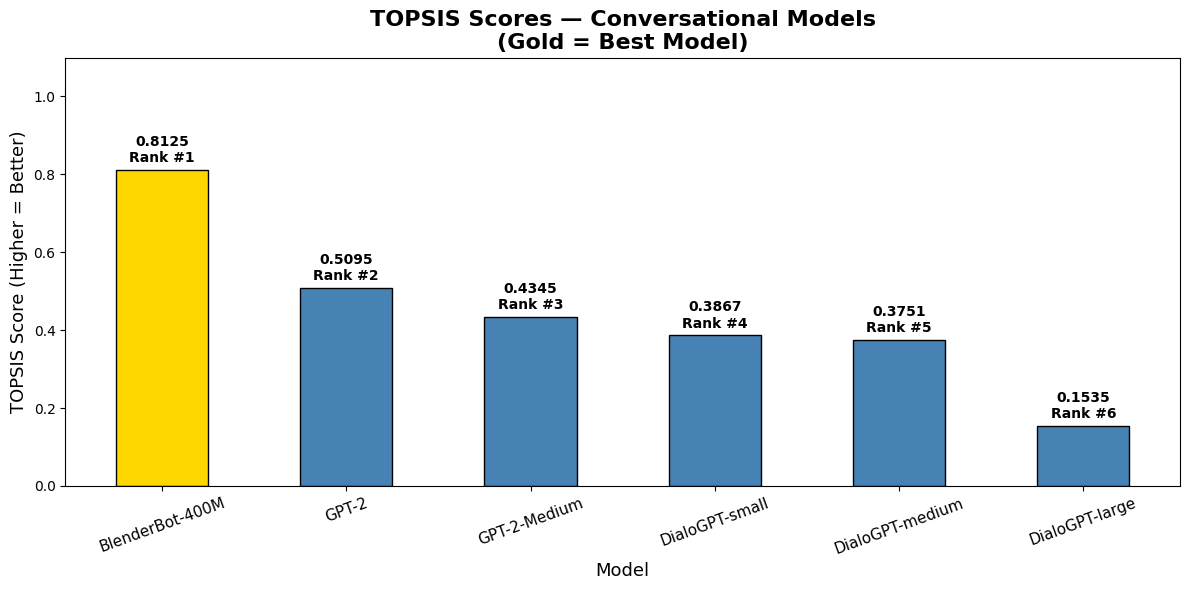

Graph 1 saved ✅


In [14]:
plt.figure(figsize=(12, 6))
colors = ['gold' if r == 1 else 'steelblue' for r in final_df['Rank']]
bars = plt.bar(final_df['Model'], final_df['TOPSIS_Score'],
               color=colors, edgecolor='black', width=0.5)

plt.title('TOPSIS Scores — Conversational Models\n(Gold = Best Model)',
          fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=13)
plt.ylabel('TOPSIS Score (Higher = Better)', fontsize=13)
plt.xticks(rotation=20, fontsize=11)
plt.ylim(0, 1.1)

for bar, score, rank in zip(bars, final_df['TOPSIS_Score'], final_df['Rank']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{score}\nRank #{rank}',
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('topsis_scores.png', dpi=150)
plt.show()
print("Graph 1 saved ✅")

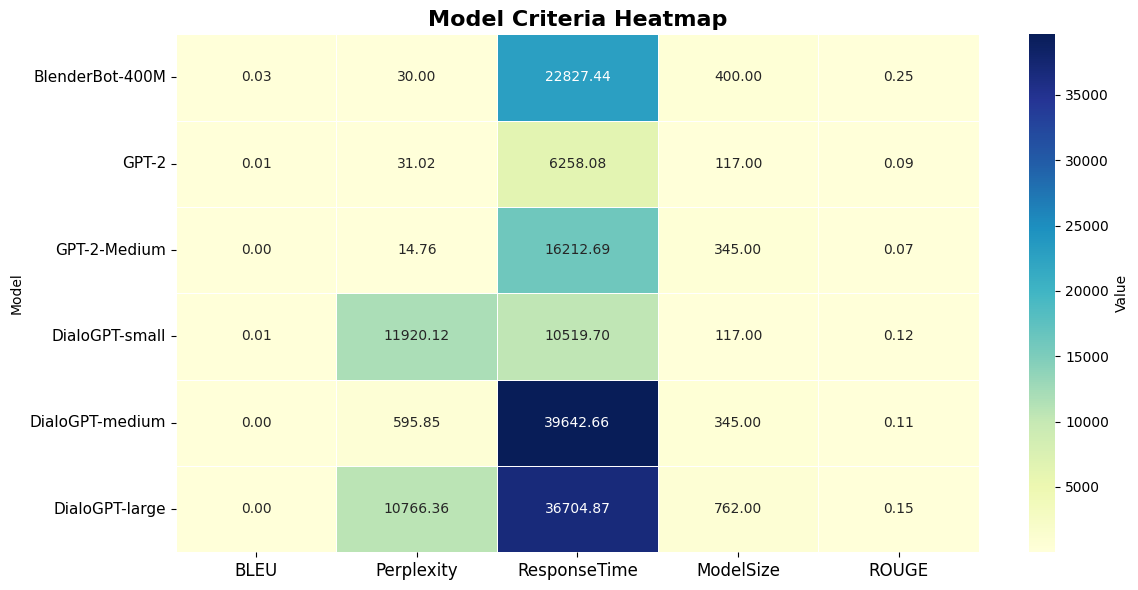

Graph 2 saved ✅


In [15]:
plt.figure(figsize=(12, 6))
heatmap_data = final_df[criteria].set_index(final_df['Model'])
sns.heatmap(heatmap_data,
            annot=True,
            fmt='.2f',
            cmap='YlGnBu',
            linewidths=0.5,
            cbar_kws={'label': 'Value'})
plt.title('Model Criteria Heatmap', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150)
plt.show()
print("Graph 2 saved ✅")

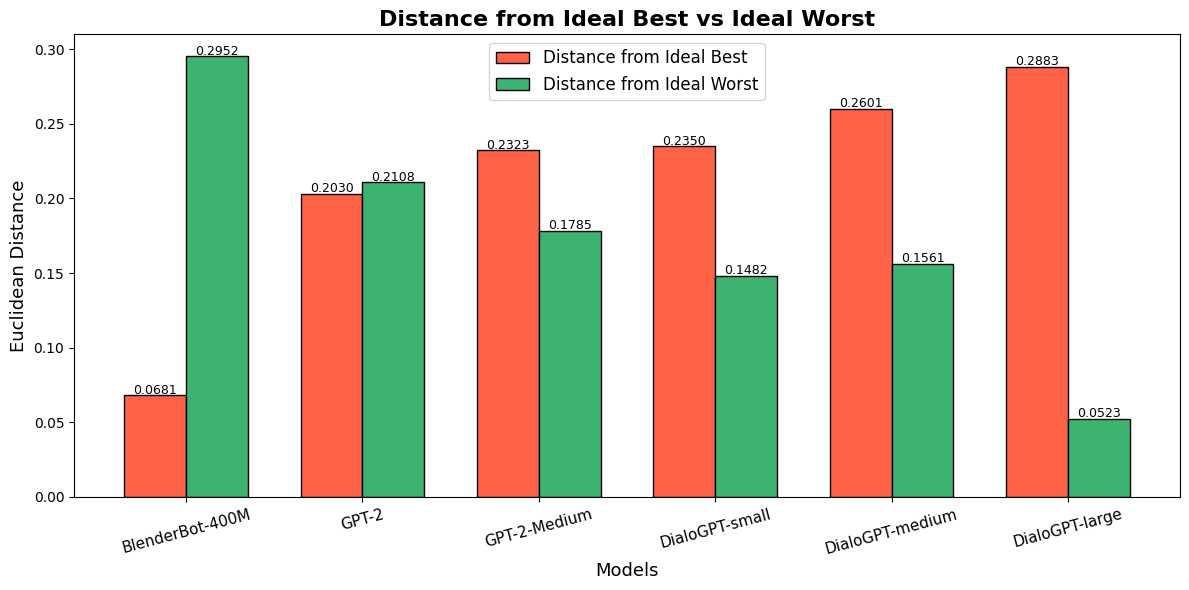

Graph 3 saved ✅


In [16]:
x = np.arange(len(final_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, final_df['Distance_Best'],
               width, label='Distance from Ideal Best',
               color='tomato', edgecolor='black')
bars2 = ax.bar(x + width/2, final_df['Distance_Worst'],
               width, label='Distance from Ideal Worst',
               color='mediumseagreen', edgecolor='black')

ax.set_xlabel('Models', fontsize=13)
ax.set_ylabel('Euclidean Distance', fontsize=13)
ax.set_title('Distance from Ideal Best vs Ideal Worst',
             fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(final_df['Model'], rotation=15, fontsize=11)
ax.legend(fontsize=12)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{bar.get_height():.4f}',
            ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{bar.get_height():.4f}',
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('distance_chart.png', dpi=150)
plt.show()
print("Graph 3 saved ✅")

In [17]:
from google.colab import files

for filename in ['model_results.csv',
                 'topsis_results.csv',
                 'topsis_scores.png',
                 'heatmap.png',
                 'distance_chart.png']:
    files.download(filename)
    print(f"Downloaded: {filename} ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: model_results.csv ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

Downloaded: heatmap.png ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: distance_chart.png ✅


FileNotFoundError: Cannot find file: radar_chart.png